# Анализ поиска в Яндекс Картинках
## Сравнение запросов на разных платформах

**Автор:** Дарья Малюшицкая | **Дата:** 05.04.2026  

**Цель работы:** Проверить гипотезу, что тематика поисковых запросов заметно отличается между пользователями десктопов и мобильных устройств.  

## Данные

Семпл запросов к Яндекс Картинкам за несколько недель (файл `data.tsv`).  
Поля: `query` (текст запроса), `timestamp` (Unix-время), `platform` (desktop/touch).

## Ожидаемые результаты

- На **touch** (мобильные устройства) ожидаем больше развлекательных и "быстрых" запросов (поздравления, погода, мемы)
- На **desktop** (компьютеры) ожидаем больше информационных и "сложных" запросов (образование, работа, таблицы)

## Структура анализа
1. Настройка окружения
2. Загрузка и первичный анализ данных
3. Диапазон дат
4. Запросы с "ютуб"
5. Топ-10 запросов
6. Трафик по часам
7. Контрастные тематики
8. Визуализация в Yandex DataLens
9. Общие выводы
10. Что можно улучшить при следующем анализе

## 1. Настройка окружения

Импортируем необходимые библиотеки и задаём параметры отображения данных и графиков.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns',  None)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Загрузка и первичный анализ данных  

### 2.1 Загрузка данных

Загружаем файл `data.tsv`.  
Формат: TSV (разделитель — табуляция), без строки заголовков.  
Явно задаём названия колонок: `query` (текст запроса), `timestamp` (время), `platform` (тип устройства).

In [2]:
df = pd.read_csv('data.tsv', sep='\t', header=None,
                 names=['query', 'timestamp', 'platform'])
print(f"✅ Данные загружены: {len(df):,} строк")

✅ Данные загружены: 1,114,365 строк


### 2.2 Первичный осмотр данных

Проверяем структуру данных: смотрим первые строки, типы колонок, наличие пропусков

In [3]:
print("=== Первые 3 строки ===")
print(df.head(3))

print("\n=== Информация о данных ===")
df.info()

=== Первые 3 строки ===
                  query   timestamp platform
0       малевич картины  1631806465  desktop
1            психология  1631781583    touch
2  с днём рождения лена  1631771563    touch

=== Информация о данных ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114365 entries, 0 to 1114364
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   query      1114365 non-null  object
 1   timestamp  1114365 non-null  int64 
 2   platform   1114365 non-null  object
dtypes: int64(1), object(2)
memory usage: 25.5+ MB


### 2.3 Распределение запросов по платформам

Определим доступные типы устройств и количество запросов на каждой платформе.

In [4]:
print("=== Уникальные платформы ===")
print(df['platform'].unique())

print("\n=== Количество запросов по платформам ===")
print(df['platform'].value_counts())

=== Уникальные платформы ===
['desktop' 'touch']

=== Количество запросов по платформам ===
platform
touch      726101
desktop    388264
Name: count, dtype: int64


### 2.4 Преобразование времени

Значения `timestamp` хранятся в Unix-формате (количество секунд с 01.01.1970).  
Преобразуем их в читаемый формат `datetime` и извлечём час и дату для дальнейшего анализа.

In [5]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df['hour'] = df['datetime'].dt.hour
df['date'] = df['datetime'].dt.date

## 3. Диапазон дат

Определяем временной период, за который собраны данные.

In [6]:
print("=== Диапазон дат ===")
print(f"Начало: {df['datetime'].min()}")
print(f"Конец:   {df['datetime'].max()}")
print(f"Дней в выборке: {(df['datetime'].max() - df['datetime'].min()).days + 1}")

=== Диапазон дат ===
Начало: 2021-08-31 21:00:00
Конец:   2021-09-21 20:59:59
Дней в выборке: 21


**Вывод:** Данные охватывают период с 31 августа по 21 сентября 2021 года.  
Всего 21 день — достаточный объём для анализа суточной динамики и сравнения платформ.

## 4. Запросы с "ютуб"

Сравниваем долю запросов, содержащих "ютуб" или "youtube", на разных платформах.

**Метод:** Гибридный подход — фильтрация через pandas (корректная работа с кириллицей), агрегация через SQL.

In [7]:
df['yt_ru'] = df['query'].str.lower().str.contains('ютуб', na=False).astype(int)
df['yt_all'] = df['query'].str.lower().str.contains('ютуб|youtube', na=False).astype(int)
query = """
SELECT 
    platform,
    COUNT(*) as total_queries,
    SUM(yt_ru) as yt_ru_only,
    SUM(yt_all) as yt_all,
    ROUND(100.0 * SUM(yt_ru) / COUNT(*), 2) as pct_ru,
    ROUND(100.0 * SUM(yt_all) / COUNT(*), 2) as pct_all
FROM df
GROUP BY platform
"""

print(sqldf(query, locals()))

df.drop(['yt_ru', 'yt_all'], axis=1, inplace=True)

  platform  total_queries  yt_ru_only  yt_all  pct_ru  pct_all
0  desktop         388264         806    1655    0.21     0.43
1    touch         726101         732     891    0.10     0.12


**Выводы:**

- **Desktop:** 0.21% запросов содержат только "ютуб", 0.43% — с учётом "youtube"
- **Touch:** 0.10% запросов содержат только "ютуб", 0.12% — с учётом "youtube"

Доля запросов с "ютуб" выше на десктопах. Это может быть связано с тем, что пользователи компьютеров чаще ищут видео-контент для работы или учёбы, тогда как на мобильных устройствах YouTube часто используется через приложение.

## 5. Топ-10 запросов

Выявляем самые частотные запросы на каждой платформе. Это позволяет понять основные пользовательские сценарии.

In [8]:
print("=== Топ-10 запросов на desktop ===\n")

query_desktop = """
SELECT query, COUNT(*) as cnt
FROM df
WHERE platform = 'desktop'
GROUP BY query
ORDER BY cnt DESC
LIMIT 10
"""

top_desktop = sqldf(query_desktop, locals())
print(top_desktop.to_string(index=False))

print("\n=== Топ-10 запросов на touch ===\n")

query_touch = """
SELECT query, COUNT(*) as cnt
FROM df
WHERE platform = 'touch'
GROUP BY query
ORDER BY cnt DESC
LIMIT 10
"""

top_touch = sqldf(query_touch, locals())
print(top_touch.to_string(index=False))

=== Топ-10 запросов на desktop ===

                          query  cnt
                 календарь 2021 2804
             таблица менделеева 2631
                       картинки 1647
             английский алфавит 1293
           обои на рабочий стол 1143
Одноклассники (социальная сеть) 1116
              таблица квадратов  877
                        алфавит  874
              таблица умножения  867
                     карта мира  795

=== Топ-10 запросов на touch ===

                  query  cnt
с днём рождения женщине 4903
        с днём рождения 3967
с днём рождения мужчине 3623
        с днем рождения 3005
                 погода 2840
                   игры 2833
                 фильмы 2746
                новости 2708
                 музыка 2696
                   мода 2648


**Выводы:**

- **Desktop:** преобладают утилитарные запросы — календари, таблицы, обои на рабочий стол, алфавиты. Пользователи используют компьютер для работы, учёбы и организации времени.

- **Touch:** доминируют социально-ориентированные запросы — поздравления с днём рождения, погода, игры, фильмы, новости. Мобильные устройства чаще используются для личных целей и быстрого доступа к информации.

**Ключевое отличие:** на десктопе люди решают "задачи", на мобильных устройствах — ищут вдохновение, развлечения и общаются.

### Визуализация топ-10 запросов

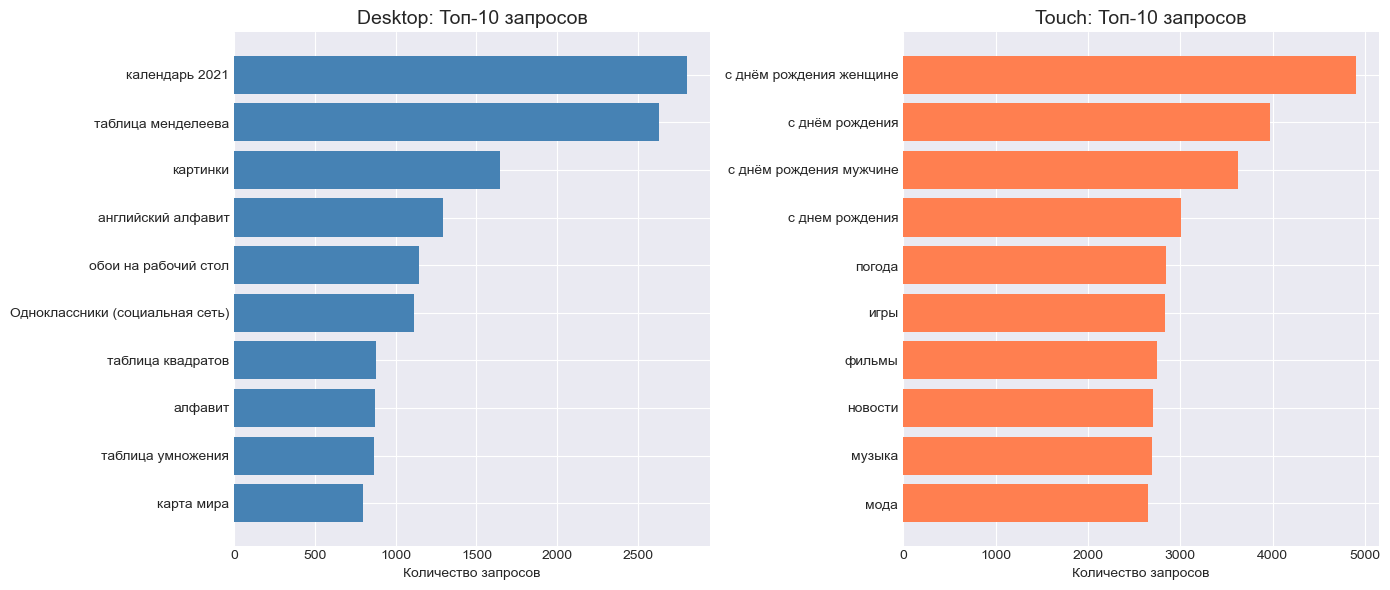

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Desktop
axes[0].barh(top_desktop['query'][::-1], top_desktop['cnt'][::-1], color='steelblue')
axes[0].set_title('Desktop: Топ-10 запросов', fontsize=14)
axes[0].set_xlabel('Количество запросов')

# Touch
axes[1].barh(top_touch['query'][::-1], top_touch['cnt'][::-1], color='coral')
axes[1].set_title('Touch: Топ-10 запросов', fontsize=14)
axes[1].set_xlabel('Количество запросов')

plt.tight_layout()
plt.show()

## 6. Трафик по часам

Анализируем суточную активность пользователей. Чтобы сравнить форму графиков на разных платформах, нормализуем данные — пиковый час принимаем за 100%.

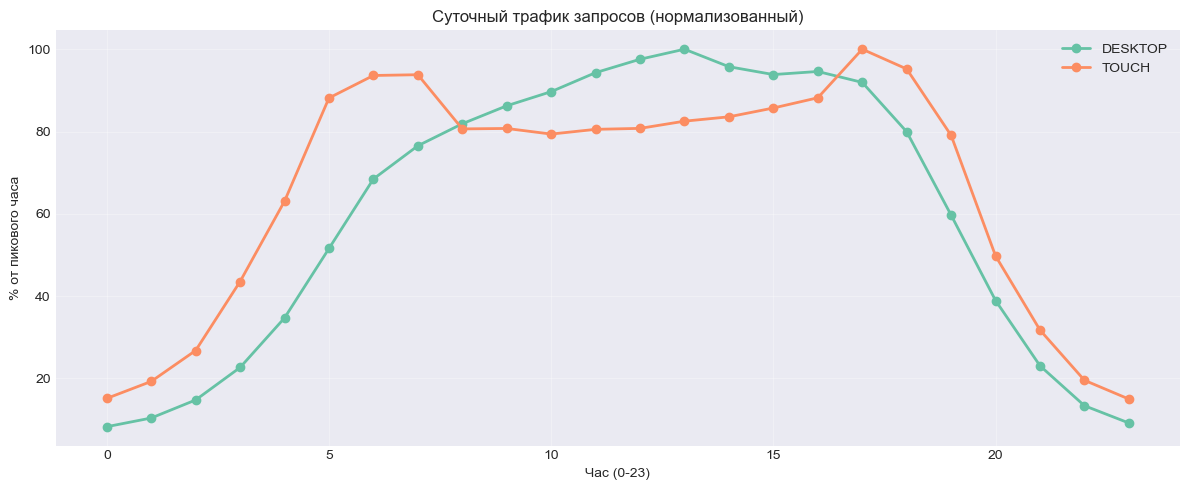


=== Часы пик ===
DESKTOP: час 13 (27,013 запросов)
TOUCH: час 17 (46,080 запросов)


In [10]:
hourly = df.groupby(['platform', 'hour']).size().reset_index(name='cnt')

for p in ['desktop', 'touch']:
    max_val = hourly[hourly['platform'] == p]['cnt'].max()
    hourly.loc[hourly['platform'] == p, 'pct_of_peak'] = 100 * hourly[hourly['platform'] == p]['cnt'] / max_val

plt.figure(figsize=(12, 5))

for p in ['desktop', 'touch']:
    subset = hourly[hourly['platform'] == p]
    plt.plot(subset['hour'], subset['pct_of_peak'], marker='o', linewidth=2, label=p.upper())

plt.xlabel('Час (0-23)')
plt.ylabel('% от пикового часа')
plt.title('Суточный трафик запросов (нормализованный)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Часы пик ===")
for p in ['desktop', 'touch']:
    subset = hourly[hourly['platform'] == p]
    peak_row = subset.loc[subset['cnt'].idxmax()]
    print(f"{p.upper()}: час {int(peak_row['hour'])} ({int(peak_row['cnt']):,} запросов)")

**Выводы:**

- **Desktop:** пик в 13:00 (27 013 запросов). Активность высока с 10:00 до 17:00 (>90% от пика). Ночью активность минимальна (8-10%).

- **Touch:** два пика — утренний (6:00–7:00, 93-94% от максимума) и вечерний (17:00, 46 080 запросов). В течение дня активность держится на уровне 80-88%. Ночная активность значительно выше, чем на десктопе (15-26%).

**Интерпретация:** Десктопы привязаны к рабочему времени, смартфоны сопровождают пользователя в течение всего дня с пиками в моменты "переключения" между активностями (утром и вечером).

## 7. Контрастные тематики

Классифицируем запросы по темам на основе ключевых слов и сравниваем распределение на desktop и touch.  
Темы отсортированы по степени контрастности — те, у которых доля на одной платформе значительно выше, чем на другой.

=== Доля тем по платформам (сортировка по контрастности) ===
platform              desktop  touch   diff
topic                                      
поздравления             8.46  35.11  26.65
образование             20.10   7.86 -12.23
календарь/расписание    12.49   2.93  -9.56
обои/природа            14.84   8.53  -6.31
соцсети/поиск            8.48   3.13  -5.35
мода/стиль               2.23   5.31   3.09
здоровье                 4.22   6.76   2.54
техника                  2.92   5.14   2.22
география                5.39   3.37  -2.02
животные                 5.01   3.52  -1.49
погода                   1.13   2.42   1.29
еда                      1.32   2.57   1.25
новости                  0.93   2.12   1.19
развлечения             10.84  10.15  -0.69
знаменитости             1.63   1.06  -0.57


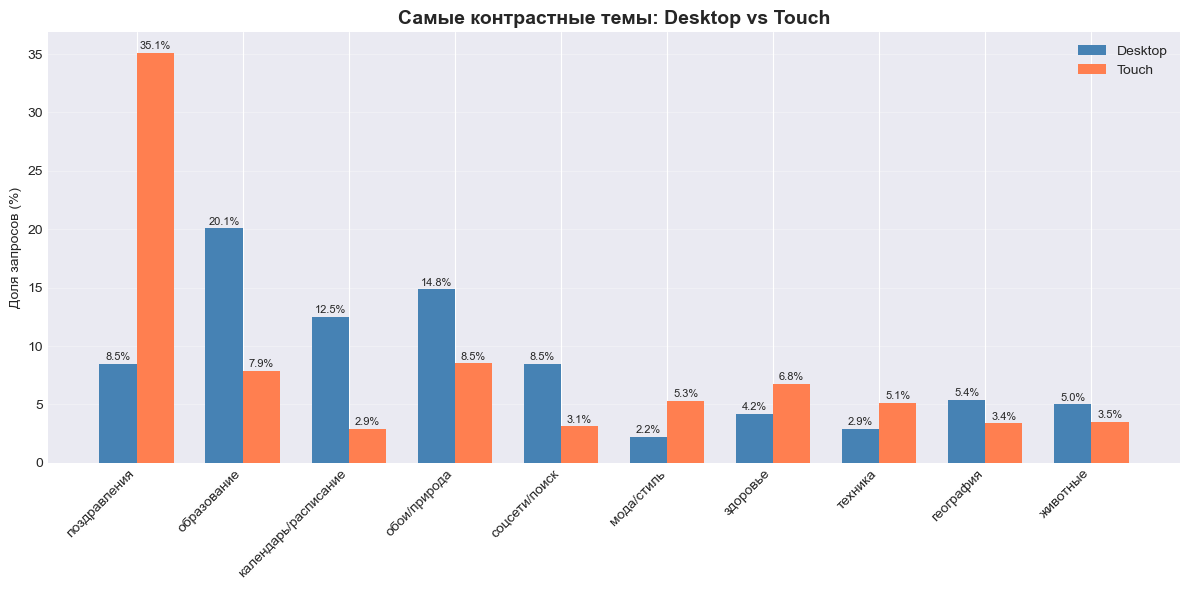


=== Самые контрастные темы ===
📱 Touch-контрастные темы (популярнее на телефонах):
поздравления: на 26.65% чаще
мода/стиль: на 3.09% чаще
здоровье: на 2.54% чаще

💻 Desktop-контрастные темы (популярнее на компьютерах):
образование: на 12.23% чаще
календарь/расписание: на 9.56% чаще
обои/природа: на 6.31% чаще


In [11]:
topics = {
    'поздравления': ['поздравлени', 'с днём рождени', 'с днем рождени', 'с праздником', 'доброе утро', 'с добрым утром', 'спокойной ночи'],
    'образование': ['таблица', 'алфавит', 'таблица менделеева', 'таблица умножени', 'английский язык', 'словарь', 'падежи', 'дискриминант',
                    'теорема', 'синтаксис', 'русский язык', 'история россии', 'литература'],
    'календарь/расписание': ['календарь', 'рабочий стол календарь', 'шаблон календаря', 'график работы', 'расписание уроков', 
                             'производственный календарь'],
    'развлечения': ['игра', 'фильм', 'музыка', 'мемы', 'приколы', 'юмор', 'кино', 'аниме', 'наруто', 'майнкрафт'],
    'погода': ['погода'],
    'новости': ['новости'],
    'мода/стиль': ['мода', 'стиль одежды', 'одежда', 'маникюр'],
    'животные': ['собак', 'кошк', 'щенок', 'котенок', 'кот'],
    'еда': ['рецепт', 'торт', 'салат рецепт', 'суп рецепт', 'пицца рецепт', 'кулинария'],
    'техника': ['айфон', 'телефон', 'ноутбук', 'компьютер'],
    'соцсети/поиск': ['одноклассники', 'вк', 'whatsapp', 'инстаграм', 'яндекс'],
    'обои/природа': ['обои на телефон', 'обои на рабочий стол', 'фон для рабочего стола', 'природ', 'осень', 'закат', 'космос', 'картинки'],
    'знаменитости': ['инстасамка', 'путин', 'певица', 'актер', 'звезда'],
    'здоровье': ['здоровье', 'психология', 'спорт'],
    'география': ['карта мира', 'карта россии', 'флаг россии', 'метро схема', 'город']
}

def get_topic(query):
    query_lower = str(query).lower()
    for topic, keywords in topics.items():
        for kw in keywords:
            if kw in query_lower:
                return topic
    return 'другое'

df['topic'] = df['query'].apply(get_topic)
df_filtered = df[df['topic'] != 'другое']

topic_by_platform = pd.crosstab(df_filtered['topic'], df_filtered['platform'], normalize='columns') * 100
topic_by_platform['diff'] = (topic_by_platform['touch'] - topic_by_platform['desktop']).round(2)
topic_by_platform = topic_by_platform.reindex(
    topic_by_platform['diff'].abs().sort_values(ascending=False).index
)

print("=== Доля тем по платформам (сортировка по контрастности) ===")
print(topic_by_platform.round(2))

fig, ax = plt.subplots(figsize=(12, 6))
topics_plot = topic_by_platform.head(10)
x = range(len(topics_plot))
width = 0.35

ax.bar([i - width/2 for i in x], topics_plot['desktop'], width, label='Desktop', color='steelblue')
ax.bar([i + width/2 for i in x], topics_plot['touch'], width, label='Touch', color='coral')

for i, (_, row) in enumerate(topics_plot.iterrows()):
    if row['desktop'] > 1:
        ax.text(i - width/2, row['desktop'] + 0.3, f"{row['desktop']:.1f}%", ha='center', fontsize=8)
    if row['touch'] > 1:
        ax.text(i + width/2, row['touch'] + 0.3, f"{row['touch']:.1f}%", ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(topics_plot.index, rotation=45, ha='right')
ax.set_ylabel('Доля запросов (%)')
ax.set_title('Самые контрастные темы: Desktop vs Touch', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Самые контрастные темы ===")

print("📱 Touch-контрастные темы (популярнее на телефонах):")
for topic, row in topic_by_platform[topic_by_platform['diff'] > 0].head(3).iterrows():
    print(f"{topic}: на {row['diff']:.2f}% чаще")

print("\n💻 Desktop-контрастные темы (популярнее на компьютерах):")
for topic, row in topic_by_platform[topic_by_platform['diff'] < 0].head(3).iterrows():
    desktop_advantage = abs(row['diff'])
    print(f"{topic}: на {desktop_advantage:.2f}% чаще")

**Выводы:**

**📱 Touch-контрастные темы (популярнее на телефонах):**
- **Поздравления:** на 26.65% чаще — мобильные устройства активно используются для поиска открыток и поздравлений.
- **Мода/стиль:** на 3.09% чаще — быстрые запросы о моде, маникюре, одежде.
- **Здоровье:** на 2.54% чаще — поиск информации о здоровье и спорте.

**💻 Desktop-контрастные темы (популярнее на компьютерах):**
- **Образование:** на 12.23% чаще — таблицы, алфавиты, словари, правила.
- **Календарь/расписание:** на 9.56% чаще — планирование, рабочие календари, расписание уроков.
- **Обои/природа:** на 6.31% чаще — оформление рабочего стола.

**Главный вывод:** Гипотеза полностью подтверждается. Телефоны — для личных, коммуникативных и "быстрых" запросов (поздравления, мода, здоровье). Компьютеры — для сложных, образовательных и рабочих задач (образование, календари, обои).

## 8. Визуализация в Yandex DataLens

Для демонстрации навыков работы с BI-инструментами построен дашборд в DataLens, включающий:
- суточный трафик по платформам,
- распределение запросов,
- топ-10 запросов (с возможностью выбора платформы через селектор).

![Дашборд DataLens](datalens_dashboard.png)

**Интерактивная версия доступна по ссылке:** [открыть дашборд в DataLens](https://datalens.yandex/lr51k6hyxmm65)

## 8. Общие выводы

Проведённый анализ подтверждает гипотезу: интересы пользователей на мобильных устройствах (touch) и компьютерах (desktop) заметно отличаются.

### Ключевые отличия

| Критерий | Desktop | Touch |
|----------|---------|-------|
| **Доля запросов с "ютуб"** | 0.43% | 0.12% |
| **Пик активности** | 13:00 (рабочее время) | 6:00–7:00 и 17:00 (утро/вечер) |
| **Топ-запросы** | календари, таблицы, обои | поздравления, погода, игры |
| **Контрастные темы** | образование, работа | поздравления, мода, здоровье |

### Основные выводы

1. **Сценарии использования:**
   - **Desktop** — инструмент для работы и учёбы. Пользователи ищут календари, таблицы, образовательные материалы. Активность привязана к рабочему дню (пик в 13:00).
   - **Touch** — личное устройство для общения, развлечений и быстрых запросов. Пользователи ищут поздравления, погоду, игры. Активность распределена в течение дня с пиками утром и вечером.

2. **Видеоконтент:** Запросов с "ютуб" больше на десктопах (0.43% против 0.12%) — вероятно, из-за удобства просмотра на большом экране или использования в рабочих целях.

3. **Тематический профиль:**
   - **Touch-контрастные темы:** поздравления (+26.7%), мода (+3.1%), здоровье (+2.5%)
   - **Desktop-контрастные темы:** образование (-12.2%), календари (-9.6%), обои (-6.3%)

### Рекомендации

- Для **мобильной версии** Яндекс Картинок стоит усилить выдачу по запросам, связанным с поздравлениями, модой и здоровьем — именно эти темы наиболее востребованы на touch.
- Для **десктопной версии** — делать акцент на образовательном и рабочем контенте (таблицы, календари, схемы).

### Ограничения анализа

- Данные охватывают только 21 день (август–сентябрь 2021), что не позволяет учесть сезонные колебания.
- Классификация тематик основана на ручном подборе ключевых слов, возможны погрешности.

### Заключение

Гипотеза о различии интересов пользователей на разных платформах **полностью подтверждена**. Полученные результаты могут быть использованы для персонализации поисковой выдачи и улучшения пользовательского опыта на Яндекс Картинках.

## 9. Что можно улучшить при следующем анализе

1. **Больше данных** — текущая выборка за 21 день (август–сентябрь). Добавление данных за другие сезоны позволит учесть сезонность.

2. **Анализ по дням недели** — поведение пользователей в выходные может отличаться от будней.

3. **Автоматическая классификация тематик** — вместо ручного подбора ключевых слов использовать алгоритмы машинного обучения для выделения тем (например, LDA). Это позволит обрабатывать больше данных и находить скрытые паттерны.

4. **A/B-тест** — провести эксперимент с разными алгоритмами выдачи на desktop и touch.

5. **Анализ глубины сессии** — сколько запросов делает пользователь за один визит.

6. **Языковая классификация** — разделить запросы на русском и других языках.